# Morphology profile analysis: per-site and cross-site UMAP

This notebook analyzes well-level Cell Painting morphology profiles produced
by five data-production sites (`aggregated_data/<SITE>/`). Every site ran the
**same plate design** (7 plates `B1001`-`B1007`, each measured across 4
replicates `R1`-`R4`), so each of the 28 CSV files in a site folder
corresponds to one plate x replicate acquisition and is treated as the
natural unit of a "batch" for normalization.

The raw `Metadata_Plate`/`Metadata_Batch` columns embedded in the CSVs are
**not consistent across sites**: for `FMP_HepG2` they cleanly hold the plate
ID and replicate; for the other four sites `Metadata_Plate` holds the
combined `"B100X_RY"` string and `Metadata_Batch` holds a constant
cell-line/dose descriptor instead. To get comparable labels everywhere, this
notebook parses the plate ID and replicate directly out of the filename
(`Metadata_PlateID`, `Metadata_Replicate`) and uses those for all grouping,
coloring, and normalization below.

Pipeline (via [`pycytominer`](https://github.com/cytomining/pycytominer)):

1. **Load** all per-plate CSVs for a site and concatenate them.
2. **Normalize** features per plate/replicate file (`mad_robustize`, robust
   z-scores against the whole-plate population, since no negative-control
   wells are annotated in these files).
3. **Feature-select**: drop low-variance, near-constant, highly-correlated,
   blocklisted, and outlier-prone features.
4. **Embed**: PCA -> nearest-neighbor graph -> UMAP (via `scanpy`).

This is done **once per site** (5 analyses) and **once on the pooled data**
from all sites together, to visualize how much of the morphological variation
is explained by production site vs. plate/replicate.


In [4]:
import glob
import os
import re
import warnings

import anndata as ad
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
from pycytominer import feature_select, normalize
from pycytominer.cyto_utils import infer_cp_features
from sklearn.metrics import silhouette_score

warnings.filterwarnings("ignore")
sc.settings.verbosity = 0
plt.rcParams["figure.facecolor"] = "#fcfcfb"
plt.rcParams["axes.facecolor"] = "#fcfcfb"
plt.rcParams["font.size"] = 10


In [5]:
DATA_DIR = "aggregated_data"
SITES = sorted(
    d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))
)
# CellProfiler compartment prefixes used in these profiles (non-standard
# abbreviations: "Nuc" and "Cyto" instead of the pycytominer defaults
# "Nuclei"/"Cytoplasm").
COMPARTMENTS = ["Cells", "Nuc", "Cyto"]

RANDOM_STATE = 0
N_PCS = 50

# Fixed-order categorical palette (validated for adjacent-pair colorblind
# safety), reused consistently across all categorical color encodings below.
PALETTE = [
    "#2a78d6",  # blue
    "#eb6834",  # orange
    "#1baf7a",  # aqua
    "#eda100",  # yellow
    "#e87ba4",  # magenta
    "#008300",  # green
    "#4a3aa7",  # violet
    "#e34948",  # red
]

print(f"Found {len(SITES)} sites: {SITES}")


Found 4 sites: ['FMP_HepG2', 'IMTM_HepG2', 'MEDINA_HepG2', 'USC_HepG2']


## 1. Load raw profiles per site

In [6]:
PLATE_RE = re.compile(r"B\d{3,}")
REPLICATE_RE = re.compile(r"(?<![A-Za-z])R\d+")


def parse_plate_replicate(filename: str) -> tuple[str, str]:
    plate = PLATE_RE.search(filename).group()
    replicate = REPLICATE_RE.search(filename).group()
    return plate, replicate


def load_site_profiles(site_dir: str, site_name: str) -> pd.DataFrame:
    # Read and concatenate every per-plate CSV for one site.
    files = sorted(glob.glob(os.path.join(site_dir, "*.csv")))
    frames = []
    for f in files:
        d = pd.read_csv(f)
        feature_cols = [c for c in d.columns if not c.startswith("Metadata_")]
        d[feature_cols] = d[feature_cols].astype("float32")
        plate, replicate = parse_plate_replicate(os.path.basename(f))
        d["Metadata_SourceFile"] = os.path.basename(f)
        d["Metadata_Site"] = site_name
        d["Metadata_PlateID"] = plate
        d["Metadata_Replicate"] = replicate
        frames.append(d)
    return pd.concat(frames, ignore_index=True)


raw_profiles = {}
for site in SITES:
    raw_profiles[site] = load_site_profiles(os.path.join(DATA_DIR, site), site)

summary = pd.DataFrame(
    {
        "n_files": {s: raw_profiles[s]["Metadata_SourceFile"].nunique() for s in SITES},
        "n_wells": {s: len(raw_profiles[s]) for s in SITES},
        "n_plates": {s: raw_profiles[s]["Metadata_PlateID"].nunique() for s in SITES},
        "n_replicates": {s: raw_profiles[s]["Metadata_Replicate"].nunique() for s in SITES},
    }
)
summary


,n_files,n_wells,n_plates,n_replicates
FMP_HepG2,28,10697,7,4
IMTM_HepG2,28,10668,7,4
MEDINA_HepG2,28,10735,7,4
USC_HepG2,28,10747,7,4


## 2. Per-plate normalization

Every source CSV already corresponds to one plate x replicate measurement, so
we group on `Metadata_SourceFile` and normalize each group independently with
`pycytominer.normalize` (`mad_robustize`: robust, median/MAD-based z-scores).
No negative-control wells are annotated in these files, so `samples="all"`
uses the whole-plate well population as the normalization reference.


In [7]:
FEATURES = infer_cp_features(
    next(iter(raw_profiles.values())), compartments=COMPARTMENTS
)
print(f"{len(FEATURES)} inferred morphology features")


def normalize_per_plate(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    parts = [
        normalize(
            group,
            features=features,
            meta_features="infer",
            samples="all",
            method="mad_robustize",
        )
        for _, group in df.groupby("Metadata_SourceFile")
    ]
    return pd.concat(parts, ignore_index=True)


normalized_profiles = {
    site: normalize_per_plate(df, FEATURES) for site, df in raw_profiles.items()
}


2977 inferred morphology features


## 3. Feature selection

Remove features that are near-constant, highly correlated with another
feature, contain too many missing values, are on the pycytominer default
blocklist (known noisy/artifact-prone CellProfiler features), or blow up to
extreme values after normalization.


In [8]:
FEATURE_SELECT_OPS = [
    "variance_threshold",
    "frequency_threshold",
    "correlation_threshold",
    "drop_na_columns",
    "blocklist",
    "drop_outliers",
]


def select_features(df: pd.DataFrame, features: list[str]) -> pd.DataFrame:
    return feature_select(df, features=features, operation=FEATURE_SELECT_OPS)


selected_profiles = {
    site: select_features(df, FEATURES) for site, df in normalized_profiles.items()
}

pd.DataFrame(
    {
        "n_features_before": {s: len(FEATURES) for s in SITES},
        "n_features_after": {
            s: sum(not c.startswith("Metadata_") for c in selected_profiles[s].columns)
            for s in SITES
        },
    }
)


,n_features_before,n_features_after
FMP_HepG2,2977,668
IMTM_HepG2,2977,683
MEDINA_HepG2,2977,571
USC_HepG2,2977,545


## 4. Attach compound / control annotations

Well-level compound identity isn't in the profile CSVs themselves. The
`annotations/` folder links it in through two tables:

- one well-annotation CSV **per site** (`Metadata_Plate`, `Metadata_Well`,
  `Metadata_Batch` = replicate, `Metadata_EOS`), matching the site names in
  `aggregated_data/` 1:1;
- `EOS_pdid.csv`, bridging the library's `EOS` compound ids to the `pdid`s
  used by the compound/target reference tables.

The `EOS` ids that don't resolve through this bridge are exactly the three
non-library controls present on every plate: `DMSO` (vehicle), `Nocodazole`
(a positive control, a well-known microtubule depolymerizer), and
`Tetrandrine` (an additional positive control without established tubulin
activity). These are folded into a single `Metadata_Control` label
(`Nocodazole`, `DMSO`, `Tetrandrine`, `other`, `unannotated`) so that the
UMAPs below can be checked for a strong, independently-known morphological
phenotype (Nocodazole-driven microtubule disruption) surviving the
site/plate batch structure.

In [11]:
ANNOTATION_DIR = "annotations"

SITE_ANNOTATION_FILES = {
    "FMP_HepG2": "2022-07-08_Annotation_Bioactives_HepG2.csv",
    "IMTM_HepG2": "2023-08-14_Annotation2_IMTM_HepG2.csv",
    "MEDINA_HepG2": "2023-11-28_Annotation_MEDINA_HepG2.csv",
    "USC_HepG2": "2023-11-28_Annotation_USC_HepG2.csv",
}

NON_LIBRARY_CONTROL_GROUP = {"DMSO": "DMSO", "Nocodazole": "Nocodazole", "Tetrandrine": "Tetrandrine"}

compound_lookup = pd.read_csv(os.path.join(ANNOTATION_DIR, "2024-08-02_EOS_pdid.csv"))


def load_well_annotation(site: str) -> pd.DataFrame:
    ann = pd.read_csv(os.path.join(ANNOTATION_DIR, SITE_ANNOTATION_FILES[site]))
    ann = ann.rename(
        columns={"Metadata_Plate": "Metadata_PlateID", "Metadata_Batch": "Metadata_Replicate"}
    )
    ann = ann.merge(compound_lookup, on="Metadata_EOS", how="left")

    control = ann["Metadata_EOS"].map(NON_LIBRARY_CONTROL_GROUP)
    ann["Metadata_Control"] = np.select(
        [control == "Nocodazole", control == "DMSO", control == "Tetrandrine", ann["Metadata_pdid"].notna()],
        ["Nocodazole", "DMSO", "Tetrandrine", "other"],
        default="unannotated",
    )
    return ann[
        ["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate", "Metadata_EOS",
         "Metadata_pdid", "Metadata_Control"]
    ]


def attach_well_annotation(df: pd.DataFrame) -> pd.DataFrame:
    parts = [
        group.merge(
            load_well_annotation(site),
            on=["Metadata_PlateID", "Metadata_Well", "Metadata_Replicate"],
            how="left",
        )
        for site, group in df.groupby("Metadata_Site")
    ]
    return pd.concat(parts, ignore_index=True)


selected_profiles = {site: attach_well_annotation(df) for site, df in selected_profiles.items()}

pd.DataFrame(
    {site: selected_profiles[site]["Metadata_Control"].value_counts() for site in SITES}
).fillna(0).astype(int)

,FMP_HepG2,IMTM_HepG2,MEDINA_HepG2,USC_HepG2
Metadata_Control,,,,
DMSO,784,784,784,784
Nocodazole,56,56,56,56
Tetrandrine,56,56,56,56
other,9801,9772,9839,9851


## 5. UMAP helper functions

In [12]:
def compute_umap(df: pd.DataFrame, seed: int = RANDOM_STATE) -> ad.AnnData:
    meta_cols = [c for c in df.columns if c.startswith("Metadata_")]
    feat_cols = [c for c in df.columns if not c.startswith("Metadata_")]
    adata = ad.AnnData(
        X=df[feat_cols].to_numpy(dtype=np.float32),
        obs=df[meta_cols].astype(str).reset_index(drop=True),
    )
    n_pcs = min(N_PCS, adata.n_vars - 1, adata.n_obs - 1)
    sc.pp.pca(adata, n_comps=n_pcs, random_state=seed)
    sc.pp.neighbors(adata, random_state=seed)
    sc.tl.umap(adata, random_state=seed)
    return adata


def color_map(categories, palette=PALETTE):
    cats = sorted(set(categories))
    return {c: palette[i % len(palette)] for i, c in enumerate(cats)}


def plot_categorical_umap(ax, adata, color_col, title):
    xy = adata.obsm["X_umap"]
    labels = adata.obs[color_col].to_numpy()
    cmap = color_map(labels)
    for cat, color in cmap.items():
        mask = labels == cat
        ax.scatter(
            xy[mask, 0], xy[mask, 1], s=6, alpha=0.6, color=color,
            linewidths=0, label=cat,
        )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)
    ax.legend(
        markerscale=2.5, fontsize=8, frameon=False, loc="best",
        title=color_col.replace("Metadata_", ""),
    )


# Fixed colors/z-order for the control label: "other"/"unannotated" are the
# large background population (drawn first, muted), the three named controls
# are drawn on top so a minority group like Nocodazole stays visible.
CONTROL_COLORS = {
    "other": "#c9c9c7",
    "unannotated": "#c9c9c7",
    "DMSO": "#2a78d6",
    "Tetrandrine": "#eda100",
    "Nocodazole": "#e34948",
}
CONTROL_DRAW_ORDER = ["other", "unannotated", "DMSO", "Tetrandrine", "Nocodazole"]


def plot_control_umap(ax, adata, title):
    xy = adata.obsm["X_umap"]
    labels = adata.obs["Metadata_Control"].to_numpy()
    for cat in CONTROL_DRAW_ORDER:
        mask = labels == cat
        if not mask.any():
            continue
        background = cat in ("other", "unannotated")
        ax.scatter(
            xy[mask, 0], xy[mask, 1],
            s=6 if background else 16,
            alpha=0.3 if background else 0.9,
            color=CONTROL_COLORS[cat],
            linewidths=0, label=cat,
            zorder=1 if background else 2,
        )
    ax.set_xlabel("UMAP1")
    ax.set_ylabel("UMAP2")
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    ax.set_title(title)
    ax.legend(markerscale=2, fontsize=8, frameon=False, loc="best", title="control")

## 6. Per-site UMAP

For each site, embed its selected/normalized features and color the same
embedding by `Metadata_PlateID`, `Metadata_Replicate`, and `Metadata_Control`
to inspect within-site plate/replicate batch structure alongside the known
Nocodazole/DMSO/Tetrandrine controls.

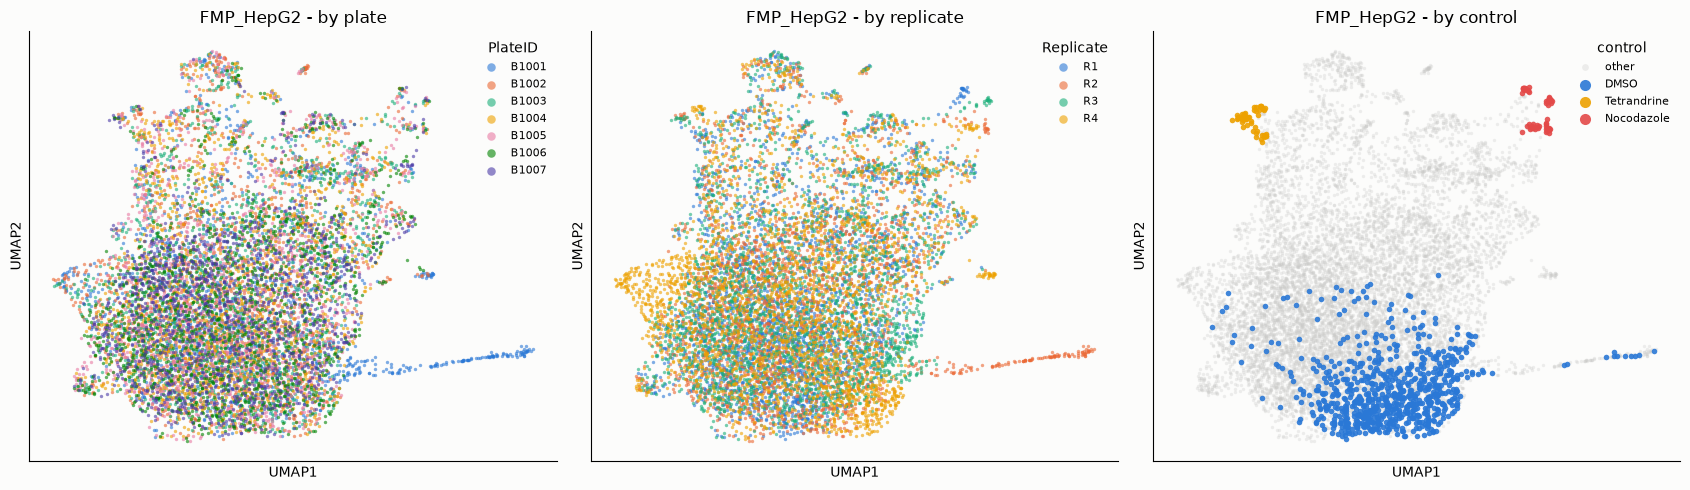

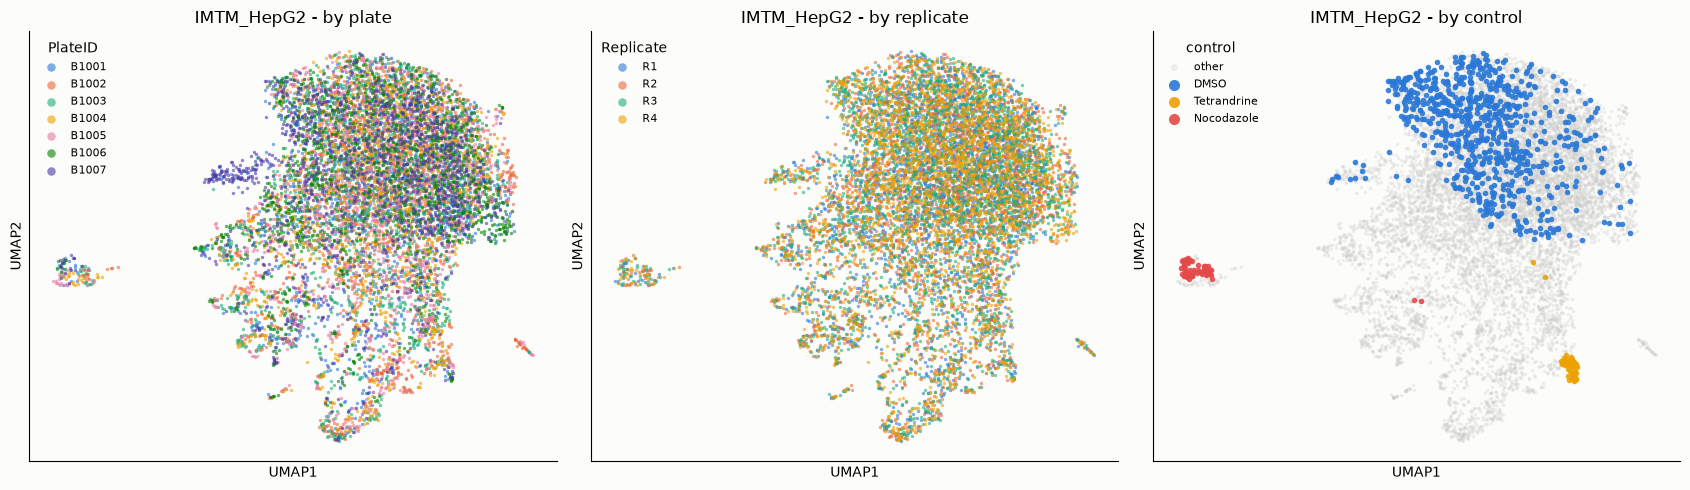

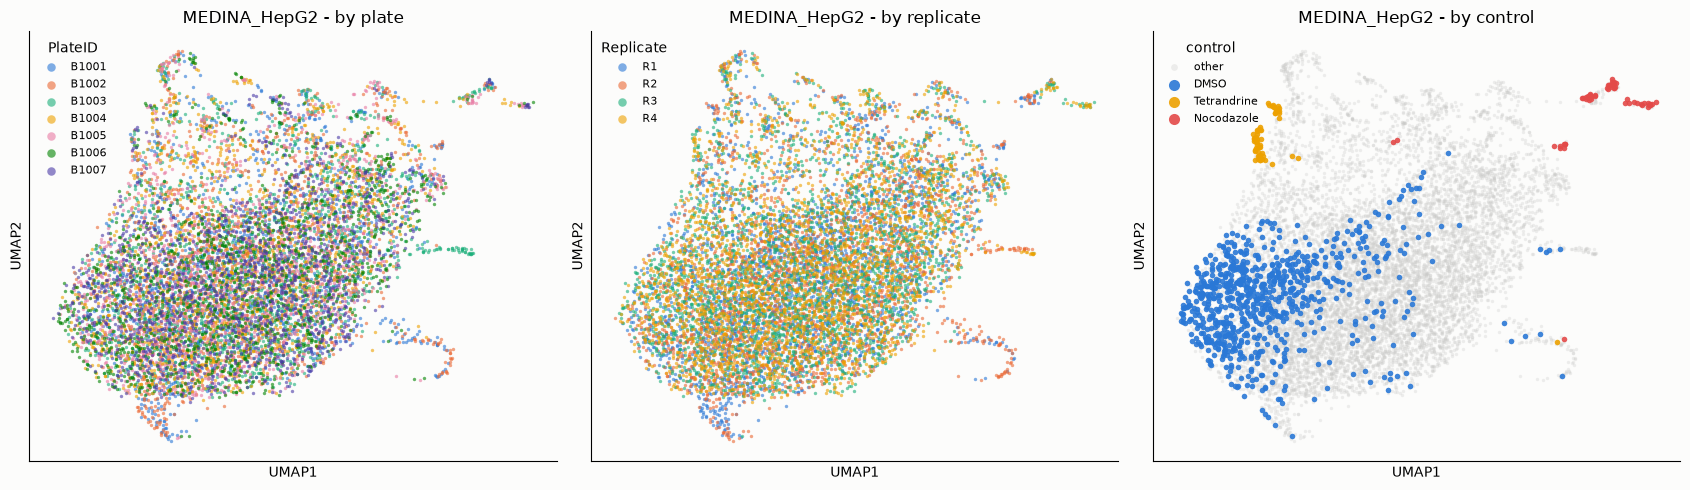

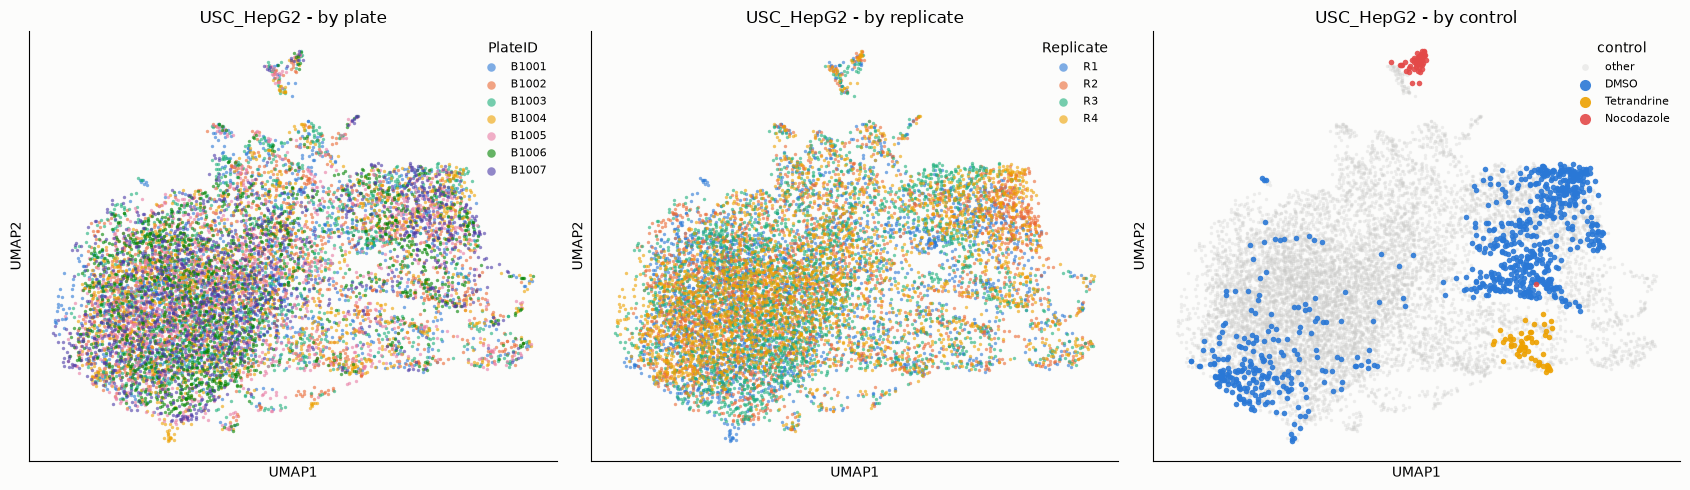

In [13]:
site_umaps = {}
for site in SITES:
    adata = compute_umap(selected_profiles[site])
    site_umaps[site] = adata

    fig, axes = plt.subplots(1, 3, figsize=(17, 5))
    plot_categorical_umap(axes[0], adata, "Metadata_PlateID", f"{site} - by plate")
    plot_categorical_umap(axes[1], adata, "Metadata_Replicate", f"{site} - by replicate")
    plot_control_umap(axes[2], adata, f"{site} - by control")
    fig.tight_layout()
    plt.show()

## 7. Combined cross-site UMAP

Pool the already per-plate-normalized profiles from all five sites (adding
`Metadata_Site`), run a fresh feature selection on the pooled data (thresholds
are recomputed on the combined population), and embed jointly. Coloring by
`Metadata_Site` shows the overall site/batch effect; coloring by
`Metadata_PlateID` shows whether wells from the same plate design (present at
every site) still cluster together across sites despite that effect; coloring
by `Metadata_Control` checks whether the Nocodazole-driven microtubule-
disruption phenotype forms a coherent group even after pooling all five
sites.

Combined: 42847 wells, 636 selected features


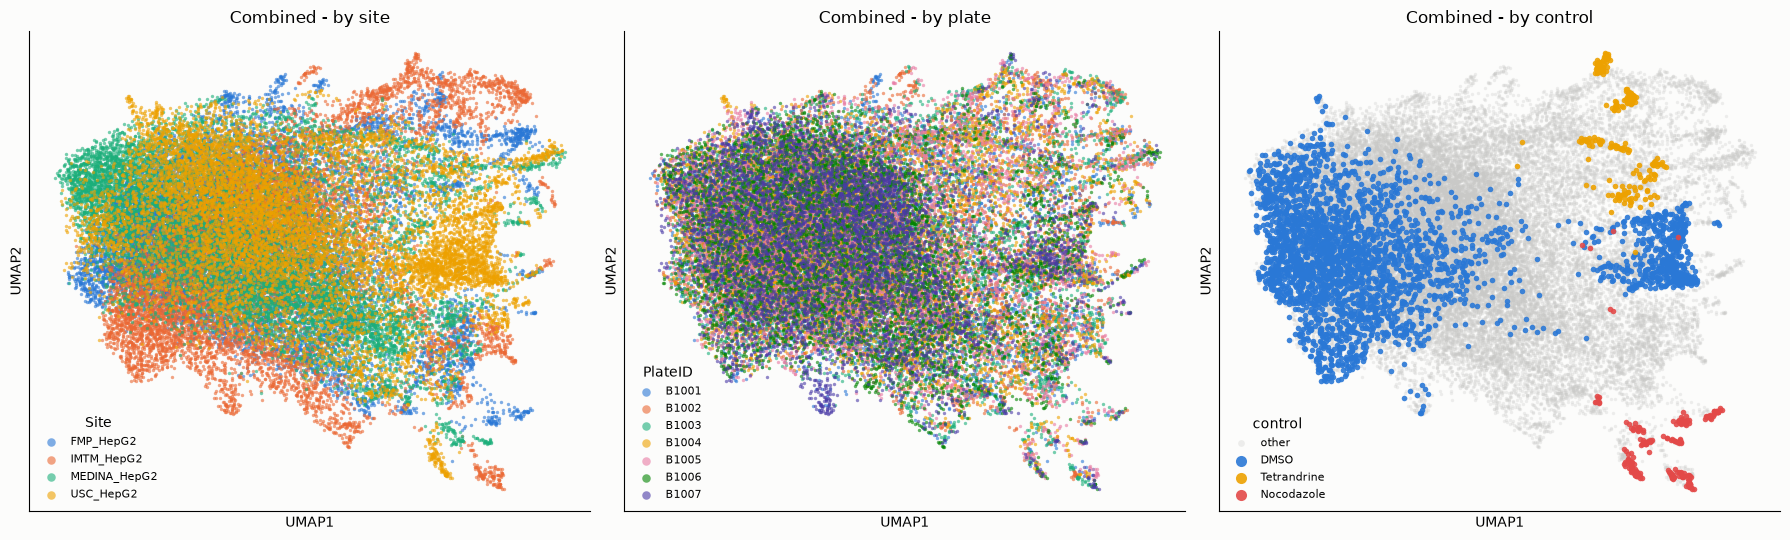

In [14]:
combined_normalized = pd.concat(normalized_profiles.values(), ignore_index=True)
combined_selected = select_features(combined_normalized, FEATURES)
combined_selected = attach_well_annotation(combined_selected)

n_feat_combined = sum(
    not c.startswith("Metadata_") for c in combined_selected.columns
)
print(f"Combined: {len(combined_selected)} wells, {n_feat_combined} selected features")

combined_umap = compute_umap(combined_selected)

fig, axes = plt.subplots(1, 3, figsize=(18, 5.5))
plot_categorical_umap(axes[0], combined_umap, "Metadata_Site", "Combined - by site")
plot_categorical_umap(axes[1], combined_umap, "Metadata_PlateID", "Combined - by plate")
plot_control_umap(axes[2], combined_umap, "Combined - by control")
fig.tight_layout()
plt.show()

## 8. How strong is the site effect, and does biology survive it?

A quick, purely descriptive check: silhouette score of the PCA embedding
using `Metadata_Site` labels, `Metadata_PlateID` labels, and `Metadata_Control`
labels. Values near `+1` mean that label cleanly separates clusters in
morphology space; values near `0` or negative mean that grouping barely
structures the data.

- A **high site silhouette** would indicate the site/batch effect dominates
  the combined embedding (a site "batch effect").
- A **high plate silhouette** (computed ignoring site) would indicate the
  shared plate design still drives clustering across sites, i.e. some
  biological/technical plate signal survives pooling.
- A **high control silhouette** would indicate that the Nocodazole/DMSO/
  Tetrandrine controls separate from the bulk of the library even after
  pooling all sites, i.e. a known, strong biological phenotype survives the
  batch structure.

In [15]:
pca_combined = combined_umap.obsm["X_pca"]
site_labels = combined_umap.obs["Metadata_Site"].to_numpy()
plate_labels = combined_umap.obs["Metadata_PlateID"].to_numpy()
control_labels = combined_umap.obs["Metadata_Control"].to_numpy()

# silhouette_score is O(n^2); subsample for speed on large combined sets
rng = np.random.RandomState(RANDOM_STATE)
n = pca_combined.shape[0]
sample_idx = rng.choice(n, size=min(n, 8000), replace=False)

site_sil = silhouette_score(pca_combined[sample_idx], site_labels[sample_idx])
plate_sil = silhouette_score(pca_combined[sample_idx], plate_labels[sample_idx])
control_sil = silhouette_score(pca_combined[sample_idx], control_labels[sample_idx])

print(f"Silhouette by Metadata_Site    : {site_sil:.3f}")
print(f"Silhouette by Metadata_PlateID : {plate_sil:.3f}")
print(f"Silhouette by Metadata_Control : {control_sil:.3f}")

Silhouette by Metadata_Site    : -0.005
Silhouette by Metadata_PlateID : -0.090
Silhouette by Metadata_Control : -0.178
